# Retrieving data & cleaning

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas_market_calendars as mcal
from scipy.stats import norm, jarque_bera, kurtosis, skew
import time

### Retrieving AAPL daily close price from 2020-01-01 to 2026-04-27

[*********************100%***********************]  1 of 1 completed


datetime64[s] <class 'pandas.DatetimeIndex'>


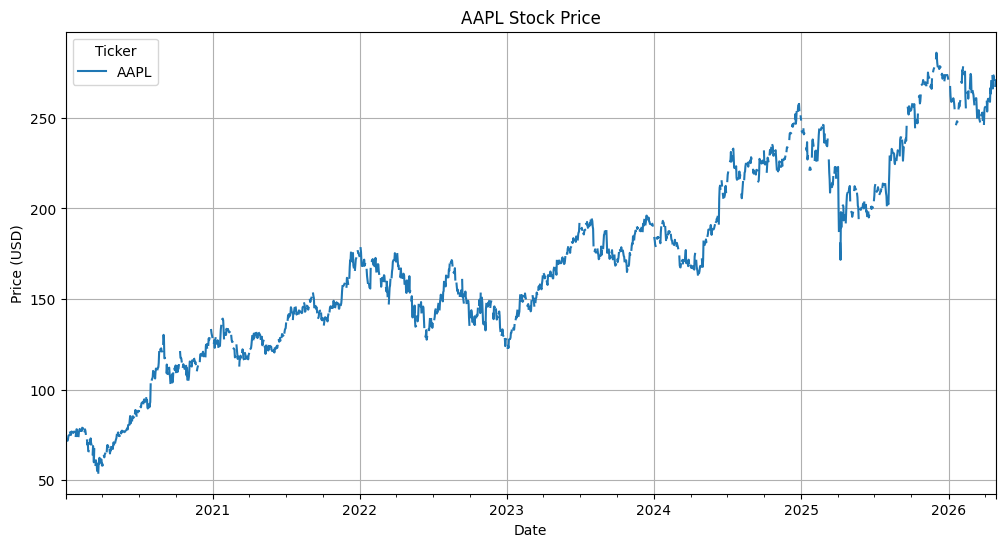

In [3]:
aapl_prices= yf.download("AAPL", start="2020-01-01", end="2026-04-29", auto_adjust=True)['Close'] #automatically adjust for splits and dividends
aapl_prices = aapl_prices.reindex(pd.date_range(aapl_prices.index.min(), aapl_prices.index.max()))
print(aapl_prices.index.dtype, type(aapl_prices.index))

#displaying the dataframe
aapl_prices.plot(title="AAPL Stock Price", figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid()
plt.show()

In [4]:
#displaying and describing the dataframe
display(aapl_prices)


#checking for missing values, and assessing when they occur + if they coincide with  NYSE weekends or holidays
print(aapl_prices.isna().any(axis=1).groupby(aapl_prices.index.day_name()).sum())

nyse = mcal.get_calendar('NYSE')
trading_days = nyse.valid_days(start_date="2020-01-01", end_date="2026-01-01").tz_localize(None)
missing_trading_days = trading_days.difference(aapl_prices.index)
print(f"Number of truly missing trading days: {len(missing_trading_days)}")
print(missing_trading_days)

#dropping missing values
aapl_prices = aapl_prices.dropna()

#checking for outliers by looking at the percentage change and filtering for changes greater than 10%
print(aapl_prices.assign(pct_change=aapl_prices['AAPL'].pct_change()).loc[aapl_prices['AAPL'].pct_change().abs() > 0.10])


Ticker,AAPL
2020-01-02,72.400520
2020-01-03,71.696655
2020-01-04,NaN
2020-01-05,NaN
2020-01-06,72.267929
...,...
2026-04-24,271.059998
2026-04-25,NaN
2026-04-26,NaN
2026-04-27,267.609985


Friday        12
Monday        34
Saturday     330
Sunday       330
Thursday      11
Tuesday        1
Wednesday      3
dtype: int64
Number of truly missing trading days: 0
DatetimeIndex([], dtype='datetime64[us]', freq=None)
Ticker            AAPL  pct_change
2020-03-13   67.164742    0.119808
2020-03-16   58.524216   -0.128647
2020-03-24   59.652599    0.100325
2020-07-31  102.978691    0.104689
2025-04-09  197.987091    0.153288


#### Missing Values & Temporal Alignment
 Analysis of the AAPL time series reveals that missing data points predominantly coincide with weekends (91.65% of missing values) and scheduled market holidays (8.35% of missing values). We recorded an average of 113.83 missing days per year, which aligns closely with the expected 115 annual non-trading days.

To ensure the integrity of the path-dependent Asian pricer, we have opted to remove these gaps rather than interpolate them. All subsequent mathematical computations, including volatility and the binomial tree's time-step Δt, will be based on a standard 252-day trading year.
 
 #### Extreme Volatility Events
 We identified five specific dates where AAPL’s daily returns exceeded a ±10% threshold. Each event was audited to determine if it represented a "fat-finger" data error or legitimate market risk. Our findings confirm these are valid historical events:

 **2020-03-13** (+11.98% daily gain): This was amid the COVID-19-induced 2020 stock market crash.  U.S. markets rallied sharply, with the Dow Jones, NASDAQ, and S&P 500 each rising over 9% in their largest single-day gains since 2008, following prior circuit breaker halts. Apple followed this trend with a strong rebound from pandemic fears and oil price collapses

 **2020-03-16** (-12.86% daily loss): Apple dropped sharply alongside broader sell-offs from escalating COVID-19 lockdowns, economic shutdowns

 **2020-03-24** ( +10.03% daily gain): Continued volatility from the crash, but markets began stabilizing. Apple rebounded as investors anticipated stimulus and saw tech resilience amid remote work shifts, though still down from pre-crash peaks. This fit the the crash end phase. 
 
 **2020-07-31** (+10.47% daily gain):  Apple surged on blowout quarterly earnings, beating expectations with $59.7 billion revenue (up 11% YoY) driven by iPhone, Services, and Mac sales amid pandemic demand. And the stock split announcement 4-1 boosted sentiment. 

 **2025-04-09** (+15.33% daily gain): This is driven by investor optimism following a temporary reprieve from severe, recently announced trade tariffs. The stock recovered from one of its worst four-day stretches since 2000. 


In [5]:
#calculating log returns and extracting the column into a separate series, dropping the first value which is NaN due to the shift
aapl_prices.loc[:, 'log return'] = np.log(aapl_prices['AAPL'] / aapl_prices['AAPL'].shift(1))
aapl_log_return = aapl_prices['log return'].dropna()

We use log returns rather than simple returns because (i) the binomial/GBM model assumes log-normality of prices, (ii) log returns are time-additive, enabling clean annualization via the $\sqrt{252}$ rule, and (iii) the CRR tree parameters  $u=e^{σ\sqrt{Δt}}$​  are derived in log-space.


In [6]:
# Save log returns as a CSV
aapl_log_return.to_csv("data/AAPL_log_returns.csv")

### Histogram of AAPL log returns

In [ ]:
# Summary statistics
mu_daily    = aapl_log_return.mean()
sigma_daily = aapl_log_return.std(ddof=1)
skew_daily  = skew(aapl_log_return)
kurt_daily  = kurtosis(aapl_log_return)  # excess kurtosis (normal = 0)
jb_stat, jb_p = jarque_bera(aapl_log_return)

print(f"Mean (daily):           {mu_daily:.6f}")
print(f"Std  (daily):           {sigma_daily:.6f}")
print(f"Skewness:               {skew_daily:.4f}")
print(f"Excess kurtosis:        {kurt_daily:.4f}")
print(f"Jarque-Bera stat:       {jb_stat:.2f}  (p-value: {jb_p:.2e})")

Mean (daily):           0.000831
Std  (daily):           0.019798
Skewness:               0.0272
Excess kurtosis:        6.4042
Jarque-Bera stat:       2712.27  (p-value: 0.00e+00)


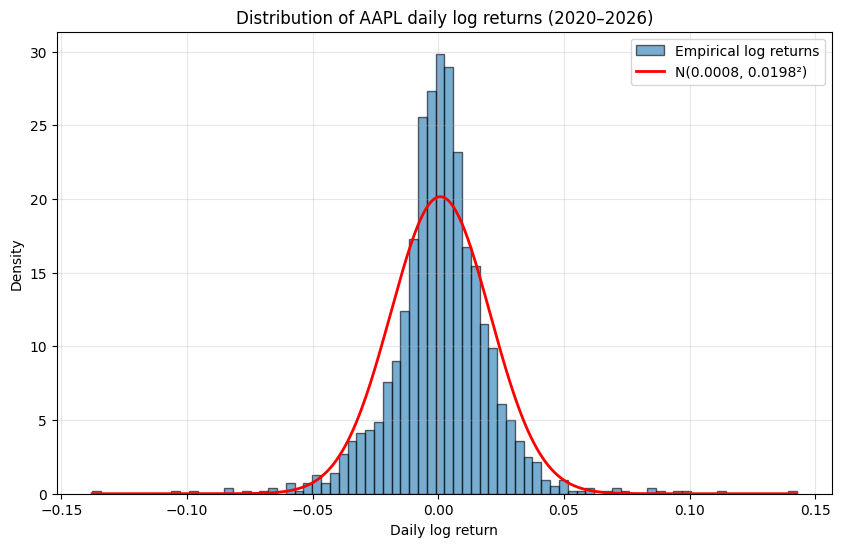

In [8]:
# Histogram with fitted normal density

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(aapl_log_return, bins=80, density=True,
        alpha=0.6, edgecolor="black", label="Empirical log returns")

x = np.linspace(aapl_log_return.min(), aapl_log_return.max(), 500)
ax.plot(x, norm.pdf(x, mu_daily, sigma_daily),
        "r-", lw=2, label=f"N({mu_daily:.4f}, {sigma_daily:.4f}²)")

ax.set_title("Distribution of AAPL daily log returns (2020–2026)")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

#### Binomial Model Assumptions
- T = 6 months
- n = 25 steps
- r = 1% p.a.
- $S_0$ = AAPL price on 28 April 2026
- u = $e^{(\sigma \sqrt{\delta t})} $, d = 1/u, p = 1/2

#### Standard deviation $\sigma$

In [9]:
# using sigma daily defined earlier:
sigma = sigma_daily * np.sqrt(250)

print(f"Daily volatility:       {sigma_daily:.6f}")
print(f"Annualized volatility:  {sigma:.6f}  ({sigma*100:.2f}%)")

Daily volatility:       0.019798
Annualized volatility:  0.313031  (31.30%)


#### Define tree parameters

In [10]:
T  = 0.5
n  = 25
r  = 0.01
dt = T / n

u = np.exp(sigma * np.sqrt(dt))
d = 1 / u                              # = np.exp(-sigma*np.sqrt(dt))
q = (np.exp(r*dt) - d) / (u - d)       # risk-neutral probability

S0 = float(aapl_prices.loc["2026-04-28", "AAPL"])

print(f"S0  = {S0:.4f}")
print(f"dt  = {dt:.6f}")
print(f"u   = {u:.6f}")
print(f"d   = {d:.6f}")
print(f"q   = {q:.6f}   (no-arb requires 0 < q < 1)")
assert 0 < q < 1, "No-arbitrage condition violated"

S0  = 270.7100
dt  = 0.020000
u   = 1.045264
d   = 0.956696
q   = 0.491193   (no-arb requires 0 < q < 1)


We calculated the risk-neutral probability q as $\frac{e^{r \Delta t} - d}{u - d}$, resulting in a value of $q \approx 0.491$. The binomial tree below is constructed using the real-world probability $p = 1/2$ while the pricing will be done using the risk-neutral probability q.

### Pricing with a binomial model

In [ ]:
def price_asian_floating(S0, sigma, r, T, n, return_terminals=False):
    """
    Price a European floating-strike Asian call via an augmented
    (S_t, C_t) binomial tree with backward induction.

    Returns the price at t=0. Optionally returns terminal payoffs
    for diagnostics.
    """
    dt   = T / n # length of one tree step in years
    u    = np.exp(sigma * np.sqrt(dt)) # up factor
    d    = 1.0 / u # down factor
    q    = (np.exp(r * dt) - d) / (u - d) # risk neutral probability
    disc = np.exp(-r * dt) # per-step discount factor
    assert 0 < q < 1, "No-arbitrage condition violated" # check no-arbitrage holds

    # Forward pass: build all 2^n terminal (S_n, C_n) pairs
    # Ordering convention: at each step, the "up" child is appended before the "down" child. This guarantees that after all n steps,
    # consecutive pairs (2k, 2k+1) at any level share the same parent, which we exploit in the backward pass.

    states = [(S0, S0)] # states is a list of tuples: each tuple is one path's current state                # t = 0: C_0 = S_0
    for _ in range(n):
        new_states = []
        for S, C in states:
            S_up = S * u
            S_dn = S * d
            new_states.append((S_up, C + S_up))   # up child first
            new_states.append((S_dn, C + S_dn))   # down child second
        states = new_states # replace old states with new ones: list is now longer

    # Terminal payoffs A_T = max(S_n - C_n/(n+1), 0) 
    payoffs = np.array(
        [max(S - C / (n + 1), 0.0) for S, C in states]
    )

    # Backward induction 
    # At each step, pair up siblings: even index = up child, odd = down child.
    # V_parent = e^(-r dt) [ q V_up + (1-q) V_down ]
    values = payoffs 
    for _ in range(n):
        values = disc * (q * values[0::2] + (1.0 - q) * values[1::2]) # discounted risk-neutral expectation 

    price = float(values[0])
    if return_terminals:
        terminals = np.array([(S, C / (n + 1)) for S, C in states])
        return price, payoffs, terminals
    return price

In [ ]:
### Run the code
t0 = time.time() # Just to see how long the model runs
price_A = price_asian_floating(S0, sigma, r, T, n)
t_A = time.time() - t0

print(f"Asian call price : {price_A:.6f}   [{t_A:.2f}s]")

Asian call price : 14.051149   [52.83s]


### Faster version (vectorized), for use later in the robustness grid

In [15]:
def price_asian_floating_vectorized(S0, sigma, r, T, n, chunk_log2=20, verbose=False):
    """
    Vectorized + chunked pricer for the European floating-strike Asian call.

    Parameters
    ----------
    S0, sigma, r, T : floats
        Spot, annualized vol, risk-free rate, maturity (years).
    n : int
        Number of binomial steps.
    chunk_log2 : int
        log2 of the chunk size in paths. chunk_log2=20 -> 2^20 paths/chunk.
        Each chunk uses roughly 2^chunk_log2 * (n+1) * 8 bytes of RAM
        (e.g. ~220 MB for chunk_log2=20, n=25).
    verbose : bool
        If True, print progress per chunk.

    Returns
    -------
    price : float
        Arbitrage-free price at t = 0.
    """
    # Calibration (same as the explicit version)
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * T)             # full-horizon discount, applied once at the end
    assert 0 < q < 1, "No-arbitrage condition violated"

    log_u, log_d = np.log(u), np.log(d)
    log_q, log_1mq = np.log(q), np.log(1.0 - q)

    # Chunking setup 
    total_paths = 1 << n                              # 2^n
    chunk_size  = min(1 << chunk_log2, total_paths)
    n_chunks    = total_paths // chunk_size

    # We accumulate the (undiscounted) Q-expected payoff in `running`.
    # Using log-space weights avoids underflow when q^k * (1-q)^(n-k)
    # gets very small for paths with extreme k.
    running_sum = 0.0

    # Pre-compute per-step bit positions (most significant bit = step 1)
    bit_positions = np.arange(n - 1, -1, -1, dtype=np.int64)

    t_start = time.time()
    for c in range(n_chunks):
        # ---- Generate this chunk's path indices ----
        idx = np.arange(c * chunk_size,
                        (c + 1) * chunk_size,
                        dtype=np.int64)[:, None]                 # (chunk, 1)

        # Decode each path index into n bits: 0 = up, 1 = down
        # (matches the "up-child first" ordering of the explicit version)
        bits = ((idx >> bit_positions) & 1).astype(np.int8)      # (chunk, n)

        # Number of up-moves per path (needed for risk-neutral weights)
        k = (bits == 0).sum(axis=1)                              # (chunk,)

        # Build price paths in log space 
        # log-step at each (path, t) = log_u if bit=0 else log_d
        log_steps = np.where(bits == 0, log_u, log_d)            # (chunk, n)

        # Cumulative log-prices, prepend log(S0) for t=0
        log_S = np.empty((bits.shape[0], n + 1))
        log_S[:, 0]  = np.log(S0)
        log_S[:, 1:] = np.log(S0) + np.cumsum(log_steps, axis=1)

        S_paths = np.exp(log_S)                                  # (chunk, n+1)

        # Payoff per path
        S_n     = S_paths[:, -1]
        S_bar_n = S_paths.mean(axis=1)                           # = C_n / (n+1)
        payoff  = np.maximum(S_n - S_bar_n, 0.0)                 # (chunk,)

        # Risk-neutral weights (in log-space for stability)
        log_w = k * log_q + (n - k) * log_1mq                    # (chunk,)
        w     = np.exp(log_w)                                    # (chunk,)

        # Accumulate
        running_sum += float((w * payoff).sum())

        if verbose and (c % max(1, n_chunks // 10) == 0 or c == n_chunks - 1):
            elapsed = time.time() - t_start
            print(f"  chunk {c+1:>4}/{n_chunks}  "
                  f"running E_Q[A_T] ≈ {running_sum:.6f}  "
                  f"[{elapsed:.1f}s]")

    # Final price
    price = disc * running_sum
    return price

In [ ]:
# Here we run the vectorized version, which is a bit faster, and make sure it gives the same output as the explicit one
print("Running vectorized version...")
t0 = time.time()
price_V = price_asian_floating_vectorized(S0, sigma, r, T, n,
                                          chunk_log2=20, verbose=True)
t_V = time.time() - t0

print(f"\nAsian call price (vectorized) : {price_V:.6f}   [{t_V:.2f}s]")
print(f"Asian call price (explicit)   : {price_A:.6f}")
print(f"Absolute difference           : {abs(price_V - price_A):.2e}")

Running vectorized version...
  chunk    1/32  running E_Q[A_T] ≈ 0.614574  [2.6s]
  chunk    4/32  running E_Q[A_T] ≈ 2.076905  [9.9s]
  chunk    7/32  running E_Q[A_T] ≈ 3.515365  [14.9s]
  chunk   10/32  running E_Q[A_T] ≈ 4.894342  [18.9s]
  chunk   13/32  running E_Q[A_T] ≈ 6.229844  [23.6s]
  chunk   16/32  running E_Q[A_T] ≈ 7.355276  [26.8s]
  chunk   19/32  running E_Q[A_T] ≈ 8.877630  [30.2s]
  chunk   22/32  running E_Q[A_T] ≈ 10.176375  [33.3s]
  chunk   25/32  running E_Q[A_T] ≈ 11.444933  [36.7s]
  chunk   28/32  running E_Q[A_T] ≈ 12.646303  [40.5s]
  chunk   31/32  running E_Q[A_T] ≈ 13.824871  [44.7s]
  chunk   32/32  running E_Q[A_T] ≈ 14.121580  [45.9s]

Asian call price (vectorized) : 14.051149   [45.98s]
Asian call price (explicit)   : 14.051149
Absolute difference           : 5.51e-14


### Robustness checks

In [18]:
def price_robust(S0, sigma, r, T, n):
    return price_asian_floating_vectorized(
        S0, sigma, r, T, n, chunk_log2=22, verbose=False
    )

# Define grids
# r: bracket the assignment's 1% with realistic alternatives (zero rates,
# pre-COVID levels, current levels, hiking-cycle levels)
r_grid = np.array([0.000, 0.005, 0.010, 0.020, 0.030, 0.040])

# sigma: ±30% around the calibrated value, plus the calibrated point itself
sigma_multipliers = np.array([0.70, 0.85, 1.00, 1.15, 1.30])
sigma_grid = sigma * sigma_multipliers

print(f"Calibrated sigma = {sigma:.4f}")
print(f"Sigma grid       = {sigma_grid.round(4)}")
print(f"r grid           = {r_grid}")
print(f"\nTotal evaluations: {len(sigma_grid) * len(r_grid)} "
      f"(~{len(sigma_grid)*len(r_grid)*45/60:.0f} min)\n")


Calibrated sigma = 0.3130
Sigma grid       = [0.2191 0.2661 0.313  0.36   0.4069]
r grid           = [0.    0.005 0.01  0.02  0.03  0.04 ]

Total evaluations: 30 (~22 min)



In [19]:
# Run the grid 
results = np.zeros((len(sigma_grid), len(r_grid)))

t_total = time.time()
for i, s in enumerate(sigma_grid):
    for j, rate in enumerate(r_grid):
        t0 = time.time()
        results[i, j] = price_robust(S0, s, rate, T, n)
        print(f"  σ={s:.4f} (×{sigma_multipliers[i]:.2f}), r={rate:.3f}: "
              f"price = {results[i,j]:7.4f}   [{time.time()-t0:.1f}s]")

print(f"\nTotal grid runtime: {(time.time()-t_total)/60:.1f} min")

  σ=0.2191 (×0.70), r=0.000: price =  9.6194   [62.0s]
  σ=0.2191 (×0.70), r=0.005: price =  9.7815   [37.3s]
  σ=0.2191 (×0.70), r=0.010: price =  9.9451   [45.3s]
  σ=0.2191 (×0.70), r=0.020: price = 10.2769   [42.4s]
  σ=0.2191 (×0.70), r=0.030: price = 10.6150   [65.2s]
  σ=0.2191 (×0.70), r=0.040: price = 10.9593   [33.6s]
  σ=0.2661 (×0.85), r=0.000: price = 11.6774   [54.9s]
  σ=0.2661 (×0.85), r=0.005: price = 11.8375   [31.7s]
  σ=0.2661 (×0.85), r=0.010: price = 11.9990   [43.2s]
  σ=0.2661 (×0.85), r=0.020: price = 12.3255   [32.0s]
  σ=0.2661 (×0.85), r=0.030: price = 12.6570   [36.8s]
  σ=0.2661 (×0.85), r=0.040: price = 12.9934   [41.6s]
  σ=0.3130 (×1.00), r=0.000: price = 13.7334   [42.4s]
  σ=0.3130 (×1.00), r=0.005: price = 13.8918   [41.7s]
  σ=0.3130 (×1.00), r=0.010: price = 14.0511   [32.1s]
  σ=0.3130 (×1.00), r=0.020: price = 14.3730   [40.4s]
  σ=0.3130 (×1.00), r=0.030: price = 14.6988   [42.9s]
  σ=0.3130 (×1.00), r=0.040: price = 15.0287   [40.7s]
  σ=0.3600

In [20]:
# Put the results in a dataframe and then save it as a csv for later use
df_prices = pd.DataFrame(
    results,
    index=[f"{m:.2f}σ̂  ({s:.4f})" for m, s in zip(sigma_multipliers, sigma_grid)],
    columns=[f"r={r:.3f}" for r in r_grid],
)
df_prices.index.name = "Volatility"
print("\nFloating-strike Asian call price (USD):")
print(df_prices.round(4).to_string())

# Save for the report
df_prices.round(4).to_csv("data/robustness_grid.csv")


Floating-strike Asian call price (USD):
                  r=0.000  r=0.005  r=0.010  r=0.020  r=0.030  r=0.040
Volatility                                                            
0.70σ̂  (0.2191)   9.6194   9.7815   9.9451  10.2769  10.6150  10.9593
0.85σ̂  (0.2661)  11.6774  11.8375  11.9990  12.3255  12.6570  12.9934
1.00σ̂  (0.3130)  13.7334  13.8918  14.0511  14.3730  14.6988  15.0287
1.15σ̂  (0.3600)  15.7872  15.9437  16.1012  16.4186  16.7395  17.0636
1.30σ̂  (0.4069)  17.8383  17.9932  18.1487  18.4620  18.7782  19.0972


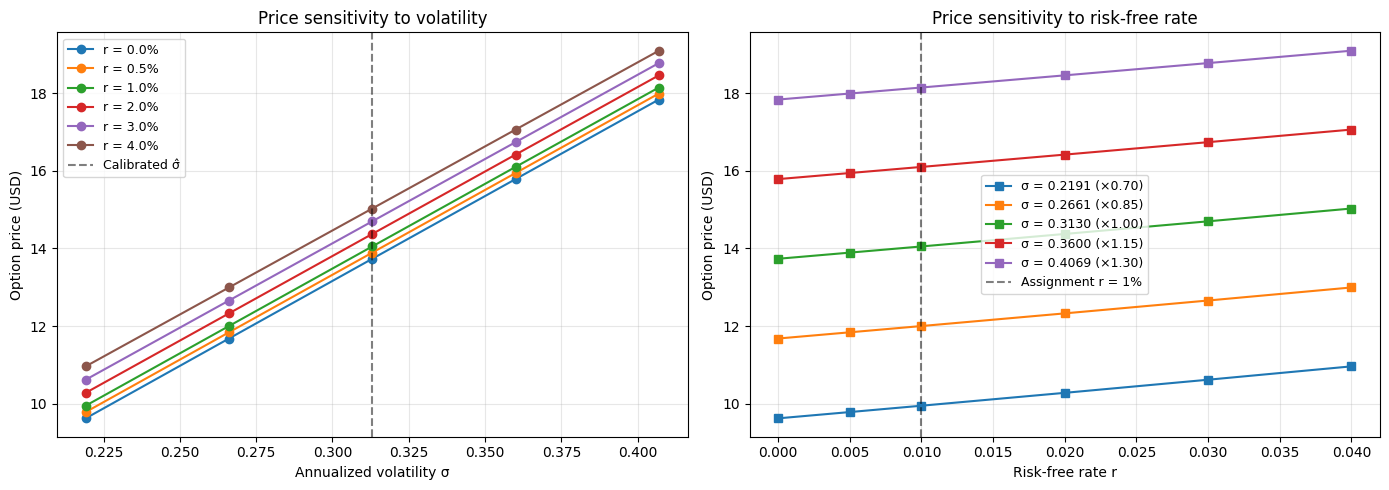

In [23]:
# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: price vs sigma, one line per r
for j, rate in enumerate(r_grid):
    ax1.plot(sigma_grid, results[:, j],
             marker="o", label=f"r = {rate:.1%}")
ax1.axvline(sigma, color="black", ls="--", alpha=0.5, label="Calibrated σ̂")
ax1.set_xlabel("Annualized volatility σ")
ax1.set_ylabel("Option price (USD)")
ax1.set_title("Price sensitivity to volatility")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Right panel: price vs r, one line per sigma
for i, s in enumerate(sigma_grid):
    ax2.plot(r_grid, results[i, :],
             marker="s", label=f"σ = {s:.4f} (×{sigma_multipliers[i]:.2f})")
ax2.axvline(0.01, color="black", ls="--", alpha=0.5, label="Assignment r = 1%")
ax2.set_xlabel("Risk-free rate r")
ax2.set_ylabel("Option price (USD)")
ax2.set_title("Price sensitivity to risk-free rate")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/robustness_check.png", dpi=150, bbox_inches="tight")
plt.show()